## Temperature change in the San Juans mountains, Colorado: An analysis of 40 years of air temperature data from the Wolf Creek climate station  

### Load python packages

In [1]:
### import libraries
import earthpy ### manage local data
import pandas as pd ### handle tabular data

### libraries for visualization
import holoviews as hv
import hvplot.pandas
import hvplot

### advanced options on matplotlib/seaborn/pandas plots
import matplotlib.pyplot as plt

### common statistical plots for tabular data
import seaborn as sns 

### fit an OLS linear regression
from sklearn.linear_model import LinearRegression

### Load the climate data for the Wolf Creek Pass Summit 

We'll be pulling data from NOAA - the Station ID is USS0006M17S. There is good data coverage for TOBS (97%), and monitoring is ongoing. Since we'll look at mean annual temperature later, we'll pull data through the end of 2025 now as not to skew the 2026 annual mean.   

To load the data, we'll make a URL containing the station ID, desired data type, and date range. 

In [2]:
### Make a URL for the data
ncei_url = ('https://www.ncei.noaa.gov/access/services/da'
            'ta/v1?dataset=daily-summaries&dataTypes=TOBS&stations'
            '=USS0006M17S&startDate=1986-08-20&endDate=2025-12-31&units=standard')

### Print the url - does it look how it should?
ncei_url

'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&stations=USS0006M17S&startDate=1986-08-20&endDate=2025-12-31&units=standard'

In [3]:
### Use the URL to pull data
wolfcreek_temp_data = pd.read_csv(
    ncei_url, ### use the URL we defined above
    index_col = 'DATE', ### index by date
    parse_dates= True, ### treat dates as dates
    na_values = ['NaN']
)

### Look at the data
wolfcreek_temp_data

,STATION,TOBS
DATE,,
1986-08-20,USS0006M17S,59.0
1986-08-21,USS0006M17S,44.0
1986-08-22,USS0006M17S,43.0
1986-08-23,USS0006M17S,41.0
1986-08-24,USS0006M17S,41.0
...,...,...
2025-12-27,USS0006M17S,20.0
2025-12-28,USS0006M17S,12.0
2025-12-29,USS0006M17S,18.0


In [4]:
### Make sure that data was imported as a pandas dataframe
type(wolfcreek_temp_data)

pandas.core.frame.DataFrame

### Clean up the dataframe and add units
The TOBS column doesn't include the unit, so we'll add that in now. We'll also remove the 'STATION' column. 

In [6]:
### Rename TOBS column to include units
wolfcreek_temp_data = wolfcreek_temp_data.rename(columns={
    'TOBS': 'temp_f',
})

## Remove 'STATION' column
wolfcreek_temp_data = wolfcreek_temp_data[['temp_f']]

### look at dataframe
wolfcreek_temp_data

,temp_f
DATE,
1986-08-20,59.0
1986-08-21,44.0
1986-08-22,43.0
1986-08-23,41.0
1986-08-24,41.0
...,...
2025-12-27,20.0
2025-12-28,12.0
2025-12-29,18.0


### Convert units
Our dataframe has units now, but our observed temperature is in fahrenheit - we need to convert to celcius. 

In [7]:
### Write function to convert units
def convert_f_to_c(temp_f): ### define function
    """Convert temperature to Celsius""" ### explain what function does - double string
    return(temp_f - 32) * 5/9

### apply to data
wolfcreek_temp_data['temp_c'] = (
    wolfcreek_temp_data['temp_f'].apply(convert_f_to_c))

### check that function worked
wolfcreek_temp_data

,temp_f,temp_c
DATE,,
1986-08-20,59.0,15.000000
1986-08-21,44.0,6.666667
1986-08-22,43.0,6.111111
1986-08-23,41.0,5.000000
1986-08-24,41.0,5.000000
...,...,...
2025-12-27,20.0,-6.666667
2025-12-28,12.0,-11.111111
2025-12-29,18.0,-7.777778


### Plot the data
Now we'll plot the data to take a preliminary look at it. 

<Axes: title={'center': 'Daily temperature on the Wolf Creek Pass Summit'}, xlabel='Date', ylabel='Temperature ($^\\circ$C)'>

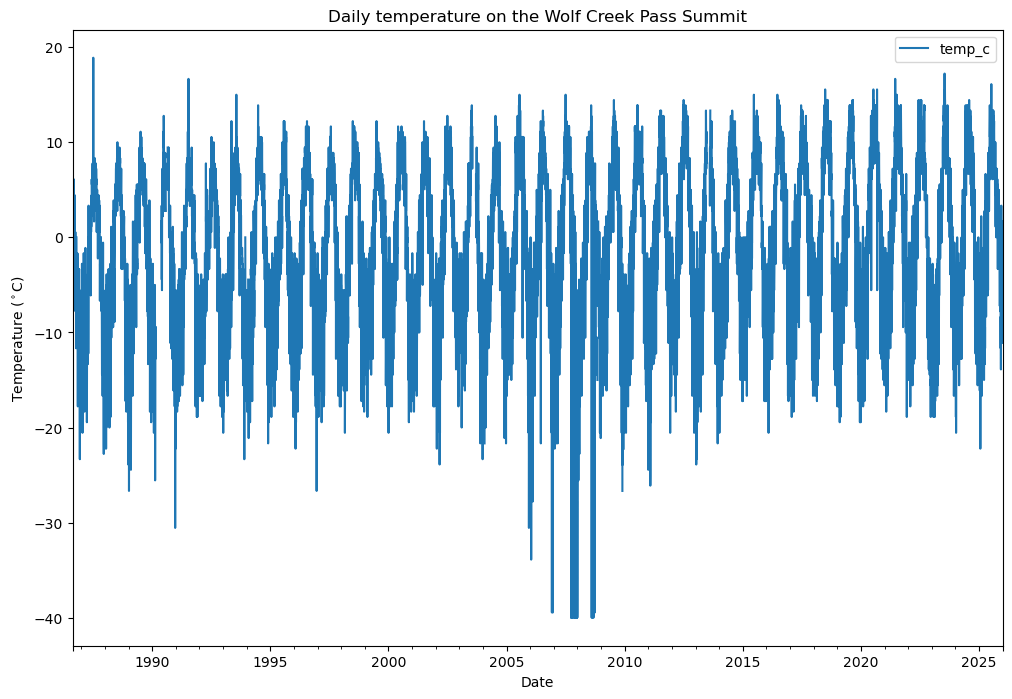

In [8]:
### plot the data using .plot
wolfcreek_temp_data.plot(
    y = 'temp_c', ### data for y axis - temperature column
    title = 'Daily temperature on the Wolf Creek Pass Summit', ### title plot
    xlabel = 'Date', ### label x axis
    ylabel = 'Temperature ($^\circ$C)', ### label y axis
    figsize=(12, 8))

It looks like there are some abnormaly low readings - what's going on with that? We'll go back to the original data to take a look.   

It looks like there are 16 readings within the record (between 20070925 and 20080905) where temperature was recorded as -40.0ºF (also -40.0ºC). There are 21 readings within the record (between 20061202 and 20080926) where temp was recorded at -39.0ºC. With both the -39.0ºC and -40.0ºC readings, the values in the days before/after are much higher. 

After a little googling and some cross-referencing with SNOTEL air temperature sensor data, it seems like these winters were particularly cold and brought a lot of heavy snow. These values may be real, or they may be measurement errors. There aren't enough metadata to make a decision on how these data should be QAQC'ed, so we'll leave them but remember that some of the values seemed unusual when we interpret the data. 

### Resample the data and plot again
Now that we've visualized all of the available data, let's clean this up a little bit by plotting mean annual temperatures rather than all of the data. First, we'll resample the data on an annual basis to calculate the mean annual temperature. 

In [9]:
### get mean annual temp 
ann_temp_wolfcreek = ( ### write to new dataframe
    wolfcreek_temp_data ### call temp units dataframe
    .resample('YS') ### set frequency of data - start of the year
    .mean() ### add summarizing method. calculate mean annual temp value
)

### look at new dataframe
ann_temp_wolfcreek

,temp_f,temp_c
DATE,,
1986-01-01,24.549618,-4.139101
1987-01-01,25.958678,-3.356290
1988-01-01,26.312329,-3.159817
1989-01-01,28.162088,-2.132173
1990-01-01,27.012048,-2.771084
1991-01-01,26.413699,-3.103501
1992-01-01,27.237705,-2.645719
1993-01-01,27.179941,-2.677811
1994-01-01,29.057803,-1.634554


### Plot the mean annual temperature. 

<Axes: title={'center': 'Mean annual temperature on the Wolf Creek Pass Summit'}, xlabel='Year', ylabel='Temperature ($^\\circ$C)'>

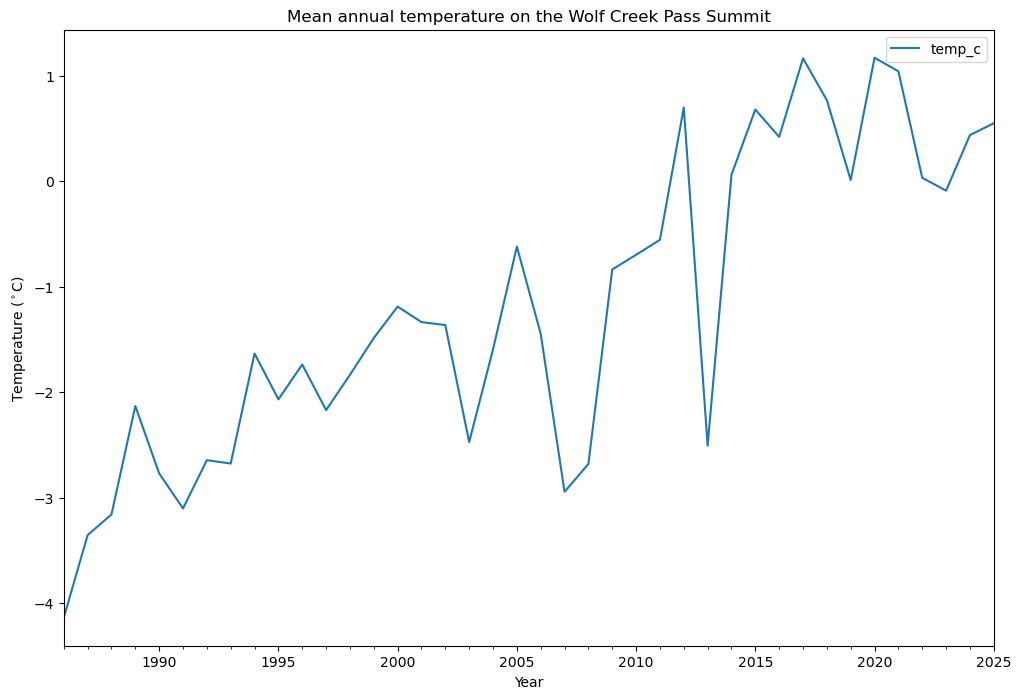

In [10]:
### plot mean annual temperature
ann_temp_wolfcreek.plot(
    y = 'temp_c', ### plot temp column (in celcius)
    title = 'Mean annual temperature on the Wolf Creek Pass Summit', ### title plot
    xlabel = 'Year', ### label x axis
    ylabel = 'Temperature ($^\circ$C)', ### label y axis
    figsize = (12,8) ### change plot dimensions
)

### Make an interactive plot

In [11]:
hvplot.extension("bokeh")

In [14]:
### plot the annual data interactively using hv plot
ann_temp_wolfcreek_plot = ann_temp_wolfcreek.hvplot(
    y = 'temp_c', ### plot temp column (in celcius)
    title = 'Mean annual temperature on the Wolf Creek Pass Summit', ### title plot
    xlabel = 'Year', ### label x axis
    ylabel = 'Temperature (deg C)', ### label y axis
)

### save plot
hv.save(ann_temp_wolfcreek_plot, 'ann_temp_wolfcreek_plot.html')

### view the plot
ann_temp_wolfcreek_plot

:Curve   [DATE]   (temp_c)

### Add a trendline 
Let's add trendline using OLS linear regression to quantify how much the climate is changing. 

In [15]:
### Reshape the dataframe
ann_temp_wolfcreek.index.year.values.reshape(-1,1)

array([[1986],
       [1987],
       [1988],
       [1989],
       [1990],
       [1991],
       [1992],
       [1993],
       [1994],
       [1995],
       [1996],
       [1997],
       [1998],
       [1999],
       [2000],
       [2001],
       [2002],
       [2003],
       [2004],
       [2005],
       [2006],
       [2007],
       [2008],
       [2009],
       [2010],
       [2011],
       [2012],
       [2013],
       [2014],
       [2015],
       [2016],
       [2017],
       [2018],
       [2019],
       [2020],
       [2021],
       [2022],
       [2023],
       [2024],
       [2025]], dtype=int32)

In [16]:
### Subset data to just include celcius
ann_temp_wolfcreek_c = ann_temp_wolfcreek[['temp_c']]

### Subset data to include years with temperature (no missing values)
complete_wolfcreek_data = ann_temp_wolfcreek_c.loc['1941':'2023']

### View complete_data_df
complete_wolfcreek_data

,temp_c
DATE,
1986-01-01,-4.139101
1987-01-01,-3.356290
1988-01-01,-3.159817
1989-01-01,-2.132173
1990-01-01,-2.771084
1991-01-01,-3.103501
1992-01-01,-2.645719
1993-01-01,-2.677811
1994-01-01,-1.634554


In [18]:
### Fit an OLS Linear Regression to the data

### Define independent variable
### Reshape 'year' to be a 2D array for scikit-learn
ind_variable = complete_wolfcreek_data.index.year.values.reshape(-1, 1)

### Define dependent variable
dep_variable = complete_wolfcreek_data

### Make linear regression model
model = LinearRegression()

### Fit the model on the data
model.fit(ind_variable, dep_variable)

### Calculate and print metrics
print(f'Slope: {model.coef_[0]} degrees per year')

Slope: [0.10886904] degrees per year


### Add the trendline to the plot

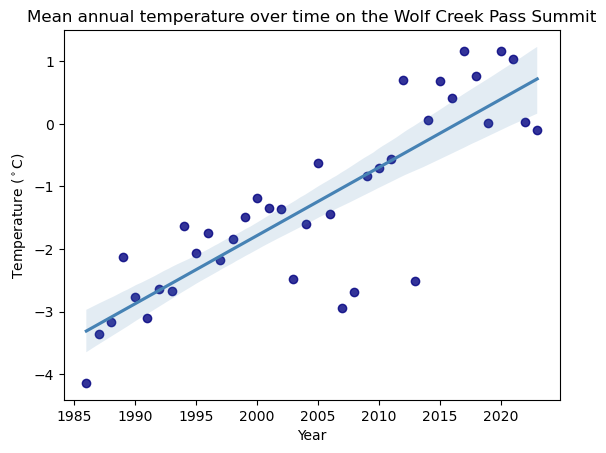

In [27]:
### plot data
ax = sns.regplot(
    x = complete_wolfcreek_data.index.year, 
    y = complete_wolfcreek_data.temp_c,

    ### change color of datapoints
    color = "navy", 

    ### change color of trendline
    line_kws = {'color':'steelblue'}
)

### make labels
ax.set(
    title = 'Mean annual temperature over time on the Wolf Creek Pass Summit',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

### plot it
plt.show()